In [3]:
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
dataHum = pd.read_excel('../dataset/Multiomics_180724_HMA analysis.xlsx', index_col='ID')
dataHum

,Date.of.Birth,Age.at.diagnosis,Sex,Date.Collection,Date.of.Diagnosis,RNA_Seq.CD34.,RNA_Seq.CD34..Run.ID,HuGe.ID,Flow.cytometry,ID.sample.Flow.BM.Tcell,...,HMA treatment,HMA start date,"OS post HMA, censored at transplant, days","OS post HMA, censored at transplant, months",OS post HMA event (1=dead; 0=censored),HMA response,HMA CR (1=yes),Venetoclax,CHT,anti_FLt3
ID,,,,,,,,,,,,,,,,,,,,,
1443593,1940-04-13,76.8,M,2017-05-24,2017-01-01,Next_seq,RNA_ESA-30,RNA_ESA-30,NaN,NaN,...,1.0,2017-01-23,438.0,14.4,1.0,CR,1.0,NaN,NaN,NaN
194521,1931-07-25,83.8,M,2016-06-04,2015-05-01,Next_seq,RNA_ESA-16,RNA_ESA-16,NaN,NaN,...,1.0,2015-05-28,1763.0,57.8,1.0,CR,1.0,NaN,NaN,NaN
5016288,1942-04-14,75.3,F,2018-09-25,2017-07-01,Next_seq,RNA_ESA-13,RNA_ESA-13,NaN,NaN,...,1.0,2017-07-15,633.0,20.8,1.0,CR,1.0,NaN,NaN,NaN
137140,1949-04-27,71.2,M,2020-06-09,2020-06-09,Run1,S32385_Lib_MDP-148,Lib_MDP-148,Yes,samples_HLU_661_015.fcs,...,1.0,2020-06-15,192.0,6.3,1.0,CR,1.0,NaN,NaN,NaN
1899884,1940-12-23,76.6,F,2017-08-03,2017-07-17,Run1,S32264_Lib_MDP-27,Lib_MDP-27,Yes,samples_ICH_ 177823_15_011.fcs,...,1.0,2017-08-08,295.0,9.7,1.0,CR,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436895,1939-06-15,77.8,M,2017-03-22,2017-03-22,NaN,NaN,NaN,Yes,samples_MDS_hlu975_BM0_006.fcs,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40073,1938-02-21,83.9,M,2022-01-10,2022-01-10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111878,1957-02-03,61.8,F,2019-11-08,2018-10-23,NaN,NaN,NaN,Yes,samples_MDS_hlu157_BM_010.fcs,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN


In [5]:
dataHum.index = dataHum.index.map(str)

In [6]:
dataHum.columns = dataHum.columns.str.strip()

In [7]:
len(dataHum.index.unique())

710

In [8]:
dataHum = dataHum.dropna(subset=['Outcome at last FU'])

duplicates = list(dataHum.index[dataHum.index.duplicated()])
dataHum.index = dataHum.index.where(~dataHum.index.duplicated(), dataHum.index + '_dp')

In [9]:
duplicates

['281766',
 '2022333',
 '1852575',
 '5070869',
 '1820744',
 '5095313',
 '5230339',
 '5031485',
 '5031485',
 '5149652',
 '5158125',
 '5147656',
 '5147656',
 '566543',
 '371217',
 '573793',
 '5168888',
 '5070869',
 '137140',
 '5189003',
 '5103839',
 '5103839',
 '5103839',
 '5145460',
 '5217078',
 '1899884',
 '1709641',
 '1739178',
 '5147289',
 '5147289',
 '5147289',
 '1679238',
 '1679238',
 '1679238',
 '1914642',
 '1914642',
 '1714115',
 '1944628',
 '1944628',
 '1944628',
 '5249238',
 '5249238',
 '5249238',
 '5249238',
 '1953250',
 '1953250',
 '1953250',
 '1953250',
 '5116490',
 '5116490',
 '314138',
 '227501',
 '227501',
 '36764',
 '36764',
 '1484',
 '16239',
 '31401',
 '137140',
 '152577',
 '232087',
 '242710',
 '270193',
 '374220',
 '480522',
 '504856',
 '1223647',
 '1418151',
 '1418151',
 '1837998',
 '1965029',
 '5027100',
 '5027100',
 '5076872',
 '5080201',
 '5121856',
 '5130029',
 '5142990',
 '5245421',
 '1665557',
 '5032640',
 '98166',
 '98166',
 '98166',
 '98166',
 '5018904',
 '5

In [10]:
white_space_check = (dataHum.applymap(lambda x: x != x.strip() if isinstance(x,str) else False)).any()

print("Colonne con spazi bianchi:")
print(white_space_check[white_space_check].index.tolist())

for col in white_space_check[white_space_check].index.tolist():
    dataHum[col] = dataHum[col].str.strip()

Colonne con spazi bianchi:
['WHO2016', 'ICC.2022', 'Type of evolution', 'Treatment 1', 'Treatment 2']


In [11]:
for slide in os.listdir('../dataset'):
    if slide.endswith(('.ndpi', '.tiff', '.tif')):
        params = slide.split('_')
        if ('YY' in params) or ('YY-ART' in params):
            print(f'{params[0]} and {params[2]}')

165857 and 431130
1144687 and 1374292
1679057 and 1583014
1686133 and 395203
1705921 and 1836126
1414537 and 90446
1418061 and 122595
1418151 and 44787
1794085 and 216668
18047758 and 420075
1627687 and 5203082
1490244 and 5192185
181885 and 1360758
1525551 and 1568741
1530497 and 1981421
1654323 and 5156108
1570455 and 5338828
1613306 and 157086
1852575 and 1528599
186539 and 1955960
1881584 and 555711
190062 and 2009167
1984604 and 5006717
2018270 and 1511212
2020648 and 1780719
276767 and 1897578
5032640 and 1890971
346788 and 5051241
35953 and 1494142
5042453 and 5242919
4142208 and 414208
49084 and 75248
50808 and 5186902
5087156 and 335357
5142836 and 401094
5197677 and 1798241
5203017 and 5214913
5213796 and 5253334
5245421 and 5011487
524219 and 97474
5230339 and 5265613
1490244 and 5192185
5310813 and 5034245
5318469 and 5129321
5338705 and 5336110
5341246 and 141840
5352209 and 1458549
5352392 and 1825903
5359594 and 1800528
5371877 and 5209017
5373126 and 5205167
5392800 and

In [9]:
#print(f"Min Date: {dataHum['Date of Diagnosis'].min()}\nMax Date: {dataHum['Date of Diagnosis'].max()}")

In [12]:
print(f"Min last FU: {dataHum['Date last FU'].min()}\nMax last FU: {dataHum['Date last FU'].max()}")

Min last FU: 2010-11-28 00:00:00
Max last FU: 2024-07-17 00:00:00


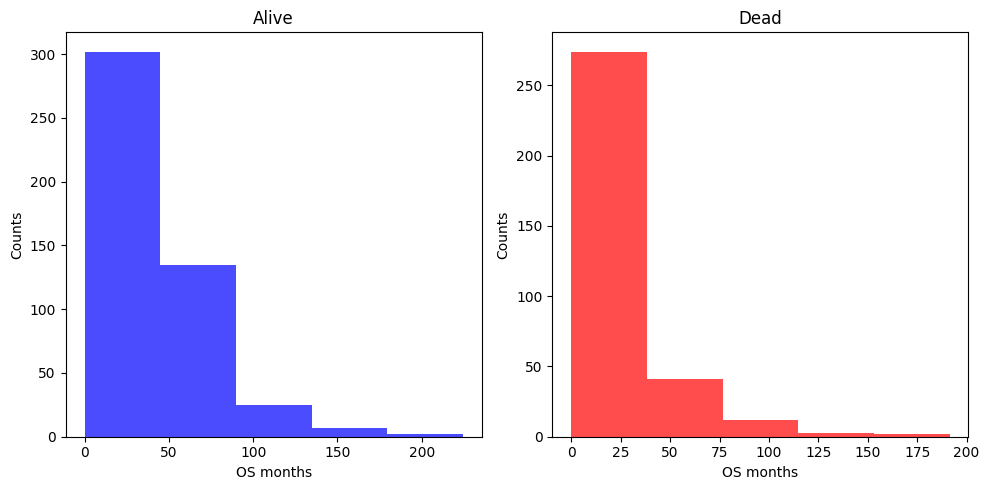

In [13]:
alive = dataHum[dataHum['Outcome at last FU'] == 'Alive']
dead = dataHum[dataHum['Outcome at last FU'].isin(['Dead', 'Death'])]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(alive['OS months'], bins=5, color='blue', alpha=0.7)
plt.title('Alive')
plt.xlabel('OS months')
plt.ylabel('Counts')

plt.subplot(1, 2, 2)
plt.hist(dead['OS months'], bins=5, color='red', alpha=0.7)
plt.title('Dead')
plt.xlabel('OS months')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()

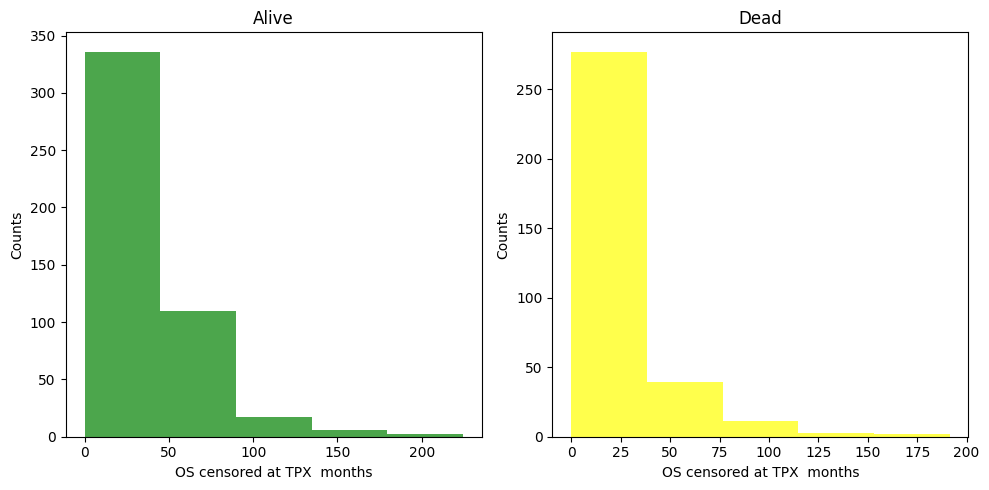

In [16]:
alive = dataHum[dataHum['Outcome at last FU'] == 'Alive']
dead = dataHum[dataHum['Outcome at last FU'].isin(['Dead', 'Death'])]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(alive['OS censored at TPX  months'], bins=5, color='green', alpha=0.7)
plt.title('Alive')
plt.xlabel('OS censored at TPX  months')
plt.ylabel('Counts')

plt.subplot(1, 2, 2)
plt.hist(dead['OS censored at TPX  months'], bins=5, color='yellow', alpha=0.7)
plt.title('Dead')
plt.xlabel('OS censored at TPX  months')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()

In [17]:
dataHum.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, 1443593 to 1851894_dp
Columns: 139 entries, Date.of.Birth to anti_FLt3
dtypes: datetime64[ns](12), float64(90), object(37)
memory usage: 878.3+ KB


In [18]:
dataHum.to_csv('../dataset_new/MultiomicsFinal.csv')

## Splits and Number of Images

In [14]:
number_of_slides = []
base_path = '../processed_images'

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        image_count = len(os.listdir(folder_path))
        number_of_slides.append((folder, folder.split('_')[0], image_count))

In [15]:
len(number_of_slides)

839

In [16]:
csv_file_path = 'folder_image_counts.csv'
with open(csv_file_path, 'w', newline='') as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(['Image_Name', 'ID', 'Count'])
    csvwriter.writerows(number_of_slides)

print(f'Data has been written to {csv_file_path}')

Data has been written to folder_image_counts.csv


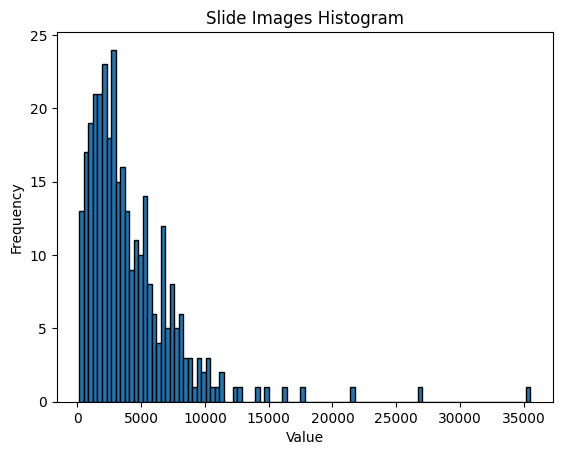

In [9]:
plt.hist([i[2] for i in number_of_slides], bins=100, edgecolor='black')
plt.title('Slide Images Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

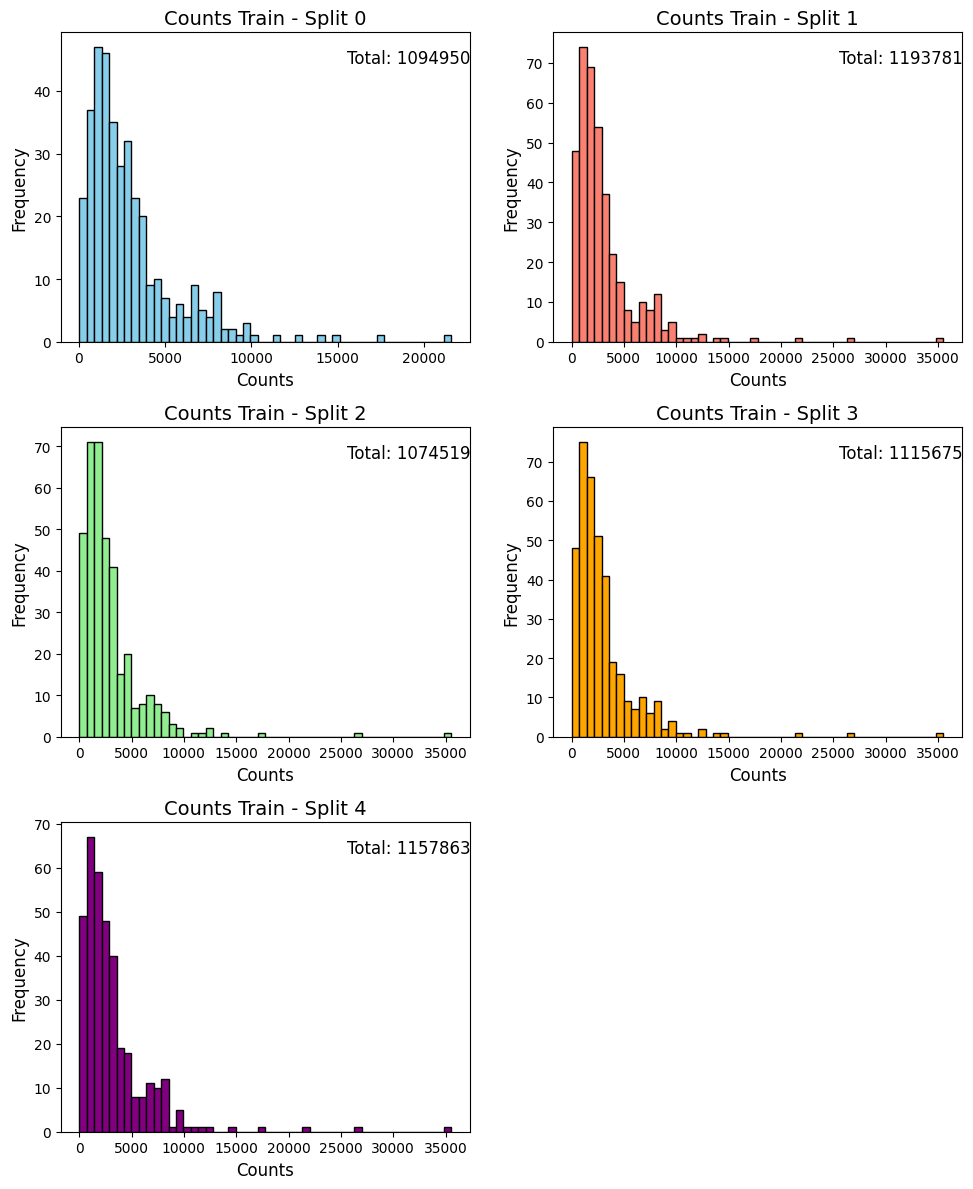

In [18]:
data = pd.read_csv('folder_image_counts.csv')

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'purple']


for i, file in enumerate(os.listdir('../splits')):
    train = pd.read_csv(os.path.join('../splits', file))
    
    train['train'] = train['train'].str.replace('_dp', '')
    filtered_data = data[data['ID'].isin(train['train'].astype(int))]
    
    total_counts = filtered_data['Count'].sum()
    
    axes[i].hist(filtered_data['Count'], bins=50, edgecolor='black', color=colors[i])
    axes[i].set_title(f'Counts Train - Split {i}', fontsize=14)
    axes[i].set_xlabel('Counts', fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    
    axes[i].text(0.7, 0.9, f'Total: {total_counts}', transform=axes[i].transAxes, fontsize=12, color='black')

for j in range(i + 1, 6):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

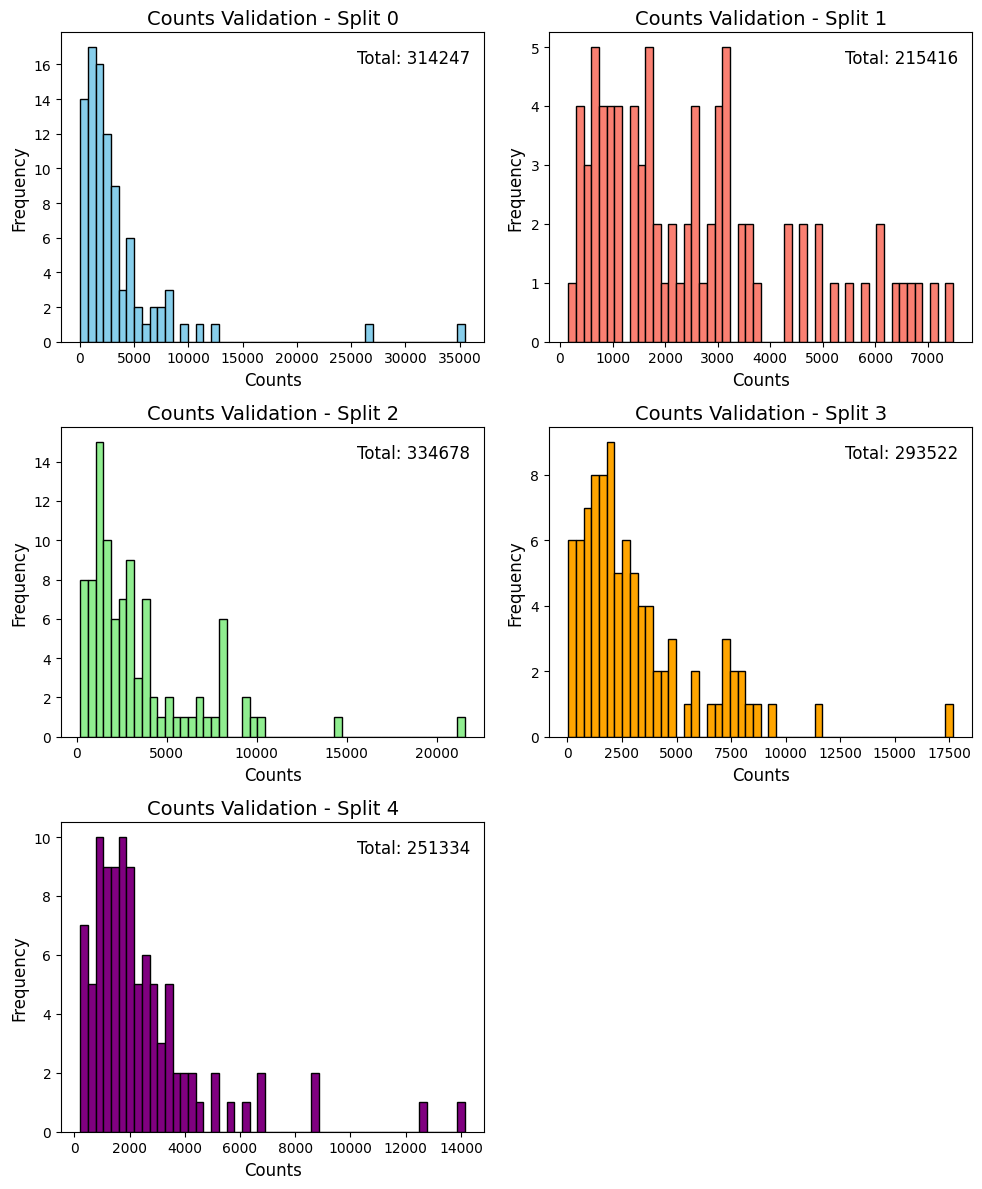

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

for i, file in enumerate(os.listdir('../splits')):
    train = pd.read_csv(os.path.join('../splits', file))
    
    train['val'] = train['val'].str.replace('_dp', '')
    filtered_data = data[data['ID'].isin(train['val'].dropna().astype(int))]
    
    total_counts = filtered_data['Count'].sum()
    
    axes[i].hist(filtered_data['Count'], bins=50, edgecolor='black', color=colors[i])
    axes[i].set_title(f'Counts Validation - Split {i}', fontsize=14)
    axes[i].set_xlabel('Counts', fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    
    axes[i].text(0.7, 0.9, f'Total: {total_counts}', transform=axes[i].transAxes, fontsize=12, color='black')

for j in range(i + 1, 6):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [21]:
import openslide

In [31]:
wsi = openslide.open_slide('../dataset/102669_20-39915_102669_20-39915_HE 3.tiff')

In [32]:
wsi.level_dimensions

((137728, 82432),
 (68864, 41216),
 (34432, 20608),
 (17216, 10304),
 (8608, 5152),
 (4304, 2576),
 (2152, 1288),
 (1076, 644),
 (538, 322),
 (269, 161))

In [33]:
wsi.level_downsamples

(1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0, 512.0)

In [29]:
wsi.level_dimensions

((72960, 66816),
 (36480, 33408),
 (18240, 16704),
 (9120, 8352),
 (4560, 4176),
 (2280, 2088),
 (1140, 1044),
 (570, 522),
 (285, 261))

In [30]:
wsi.level_downsamples

(1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0)

In [23]:
for i in wsi.properties:
    print(f'{i}: {wsi.properties[i]}')

hamamatsu.CCD.Height: -1
hamamatsu.CCD.Width: 5294
hamamatsu.Calibration.Version: 500
hamamatsu.Coarse.Focus.Pitch: 5000
hamamatsu.Coarse.Focus.Travel: 10000
hamamatsu.Condenser.NA: ÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿ5
hamamatsu.Condition2.CCD.Height: 0
hamamatsu.Condition2.CCD.Width: 0
hamamatsu.Condition2.Lane.Shift.Amount: 0
hamamatsu.Condition2.Objective.Lens.Magnificant: 1,01857e-312
hamamatsu.Condition2.Stage.Offset: 0,0,0
hamamatsu.Condition2.Vertical.Offset: 0,0
hamamatsu.Created: 2020/06/22
hamamatsu.Exposure.Barcode.Macro: 213
hamamatsu.Exposure.CassetteBarcode: 60
hamamatsu.Exposure.Slide.Darkfield.Macro: -1
hamamatsu.Exposure.Slide.Macro: 46
hamamatsu.Fine.Focus.Pitch: 250
hamamatsu.Fine.Focus.Travel: 400
hamamatsu.FocalPlane.LeftBottom: 296950,243620,113754
hamamatsu.FocalPlane.LeftTop: 296950,43620,113711
hamamatsu.FocalPlane.RightBottom: 696950,243620,114567
hamamatsu.FocalPlane.RightTop: 696950,43620,114496
hamamatsu.IlluminationLevel.Barcode.Macro: 1000
hamamatsu.Illumina